In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
exps = [
    "scream_dpxx_DYCOMSrf01_a300_p80",
    "scream_dpxx_DYCOMSrf01_a9999_p55",
    "scream_dpxx_DYCOMSrf01_a8000_p55",
    "scream_dpxx_DYCOMSrf01_a4000_p55",
    "scream_dpxx_DYCOMSrf01_a1_1",
    "scream_dpxx_DYCOMSrf01_a30_p80",
    "scream_dpxx_DYCOMSrf01_a860_p60",
    "scream_dpxx_DYCOMSrf01_a2000_p55",
    "scream_dpxx_DYCOMSrf01_a2000_p55_0ps",
    "scream_dpxx_DYCOMSrf01_a4654_p50",
    "scream_dpxx_DYCOMSrf01_a1000_p55",
]

In [111]:
data = {}; dfs = {}
for exp in exps:
    data[exp] = xr.open_mfdataset(f"/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/{exp}/run/{exp}.scream.h.INSTANT.nmins_x5.1999-*.nc")
    dfs[exp] = data[exp][["cdnc_at_cldtop", "cldfrac_liq_at_cldtop", "LiqWaterPath"]].unify_chunks().to_dataframe()

In [112]:
for df in dfs.values():
    df["LiqWaterPath"] = 100* df["LiqWaterPath"] / df["cldfrac_liq_at_cldtop"]
    df["cdnc_at_cldtop"] = df["cdnc_at_cldtop"] / df["cldfrac_liq_at_cldtop"] / 1e6

scream_dpxx_DYCOMSrf01_a300_p80
scream_dpxx_DYCOMSrf01_a9999_p55
scream_dpxx_DYCOMSrf01_a8000_p55
scream_dpxx_DYCOMSrf01_a4000_p55
scream_dpxx_DYCOMSrf01_a1_1
scream_dpxx_DYCOMSrf01_a30_p80
scream_dpxx_DYCOMSrf01_a860_p60
scream_dpxx_DYCOMSrf01_a2000_p55
scream_dpxx_DYCOMSrf01_a2000_p55_0ps
scream_dpxx_DYCOMSrf01_a4654_p50
scream_dpxx_DYCOMSrf01_a1000_p55


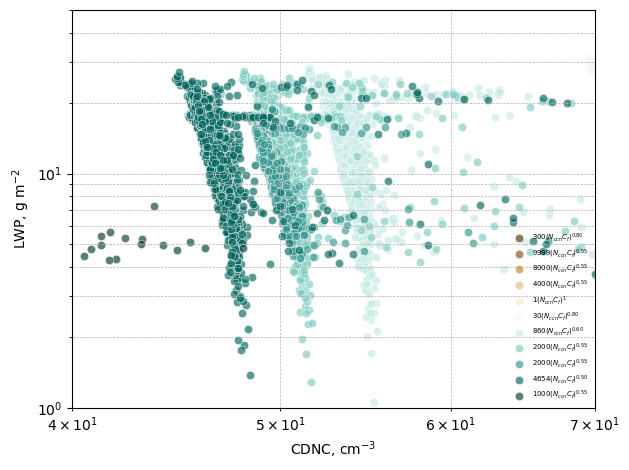

In [113]:
for exp in exps:
    print(exp)
    df = dfs[exp]
    # change color for each experiment
    colors = plt.cm.BrBG(np.linspace(0, 1, len(dfs)))
    color = colors[exps.index(exp)]
    a, b = exp.split("_")[3:5]
    a = a.replace("a", "")
    b = b.replace("p", "0.")
    sns.scatterplot(data=df, x="cdnc_at_cldtop", y="LiqWaterPath", alpha=0.65, color=color, label=f"${a} (N_{{ccn}} C_{{f}})^{{{b}}}$")
    # Set xscale and yscale to log
    plt.xscale("log"); plt.xlim(4e1, 7e1)
    plt.yscale("log"); plt.ylim(1e0, 5e1)
    plt.xlabel(f"CDNC, cm$^{{-3}}$")
    plt.ylabel(f"LWP, g m$^{{-2}}$")
    # make the grid at every minor tick
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend(bbox_to_anchor=(1.05, 0.80), loc='upper left', fontsize=10)
# remove the legend
plt.legend(loc='lower right', fontsize=5, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_zoom2.png", dpi=300, bbox_inches='tight')

In [55]:
some_df = pd.DataFrame()

some_df["cdnc"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=4).values.flatten() / 1e6
some_df["lwp"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].LiqWaterPath.values.flatten() * 100
some_df["lcc"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()

some_df["lcc0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].cldfrac_liq_at_cldtop.values.flatten()
some_df["cdnc0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].cdnc_at_cldtop.values.flatten() / 1e6
some_df["lwp0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].LiqWaterPath.values.flatten() * 100

some_df["lwp0"] /= some_df["lcc0"]
some_df["cdnc0"] /= some_df["lcc0"]
some_df["lwp"] /= some_df["lcc"]
some_df["cdnc"] /= some_df["lcc"]

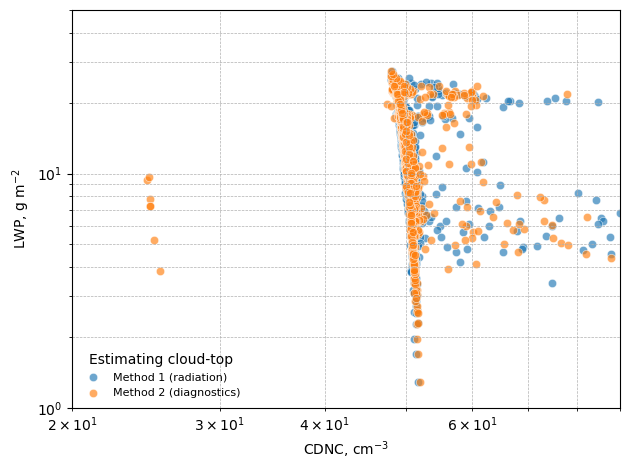

In [103]:
sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"Method 1 (radiation)")
sns.scatterplot(data=some_df, x="cdnc", y="lwp", alpha=0.65, label=f"Method 2 (diagnostics)")
# Set xscale and yscale to log
plt.xscale("log"); plt.xlim(2e1, 9e1)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False, title="Estimating cloud-top")
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_methods.png", dpi=300, bbox_inches='tight')

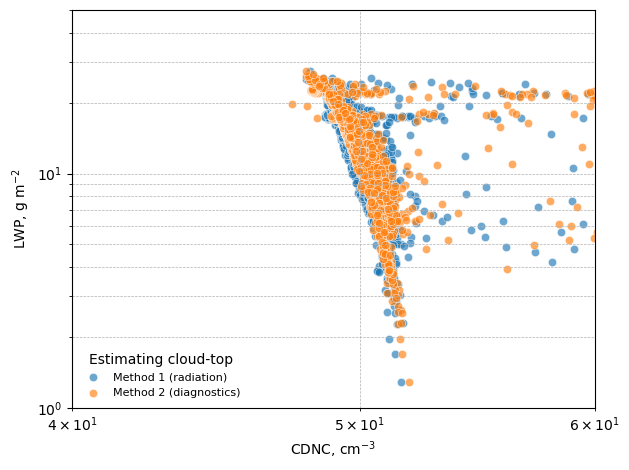

In [102]:
sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"Method 1 (radiation)")
sns.scatterplot(data=some_df, x="cdnc", y="lwp", alpha=0.65, label=f"Method 2 (diagnostics)")
# Set xscale and yscale to log
plt.xscale("log"); plt.xlim(4e1, 6e1)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False, title="Estimating cloud-top")
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_methods_zoom.png", dpi=300, bbox_inches='tight')

In [106]:
some_df["nc_top"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=8).values.flatten()/data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()
some_df["nc_bot"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldBot.isel(dim10=8).values.flatten()/data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()

/tmp/ipykernel_1957404/1024550111.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', fontsize=8, frameon=False)


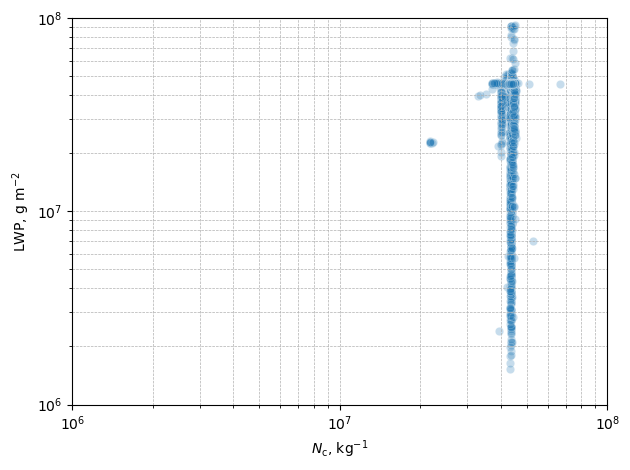

In [107]:
sns.scatterplot(data=some_df, x="nc_top", y="nc_bot", alpha=0.25)
# sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"nc_bot-lwp")
plt.xscale("log"); plt.xlim(1e6, 1e8)
plt.yscale("log"); plt.ylim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()

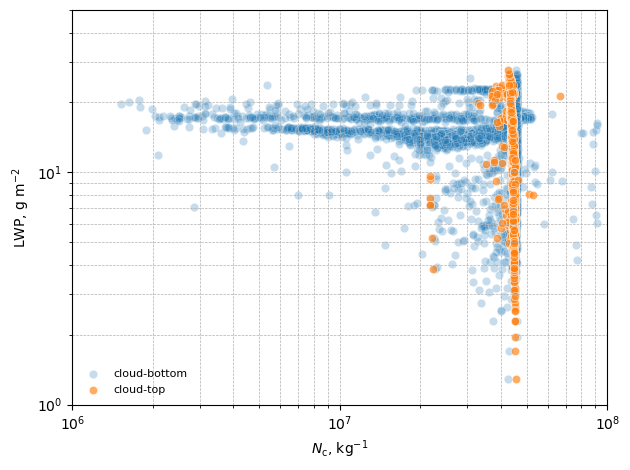

In [108]:
sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"cloud-bottom")
sns.scatterplot(data=some_df, x="nc_top", y="lwp", alpha=0.65, label=f"cloud-top")
# sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"cdnc0-lwp0")
# Set xscale and yscale to log
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
plt.xscale("log"); plt.xlim(1e6, 1e8)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp_nc_topbot.png", dpi=300, bbox_inches='tight')


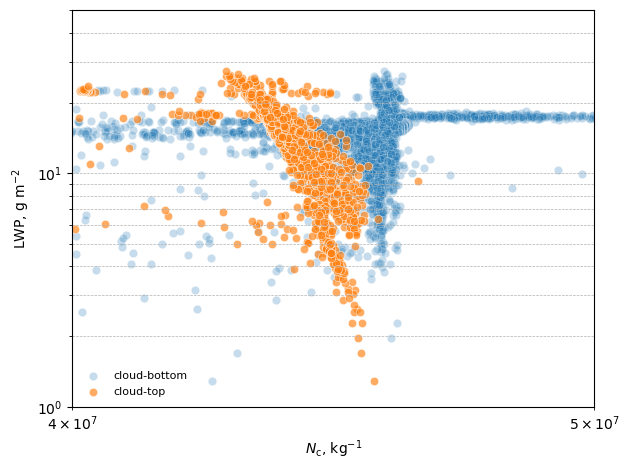

In [109]:
sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"cloud-bottom")
sns.scatterplot(data=some_df, x="nc_top", y="lwp", alpha=0.65, label=f"cloud-top")
# sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"cdnc0-lwp0")
# Set xscale and yscale to log
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
plt.xscale("log"); plt.xlim(4e7, 5e7)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp_nc_topbot_zoom.png", dpi=300, bbox_inches='tight')

In [97]:
data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop

<xarray.DataArray 'AeroComCldTop' (time: 73, ncol: 100, dim10: 10)> Size: 292kB
dask.array<open_dataset-AeroComCldTop, shape=(73, 100, 10), dtype=float32, chunksize=(73, 100, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 584B 1999-07-11 ... 1999-07-11T06:00:00
Dimensions without coordinates: ncol, dim10
Attributes: (12/13)
    units:          1
    T_mid:          0 (K)
    cdnc:           4 (#/m3)
    cldfrac_ice:    2 (nondim)
    cldfrac_liq:    3 (nondim)
    cldfrac_tot:    7 (nondim)
    ...             ...
    eff_radius_qi:  6 (micron)
    nc:             8 (1/kg)
    ni:             9 (1/kg)
    p_mid:          1 (Pa)
    long_name:      MISSING
    standard_name:  MISSING

scream_dpxx_DYCOMSrf01_a2000_p55
scream_dpxx_DYCOMSrf01_a2000_p55_0ps


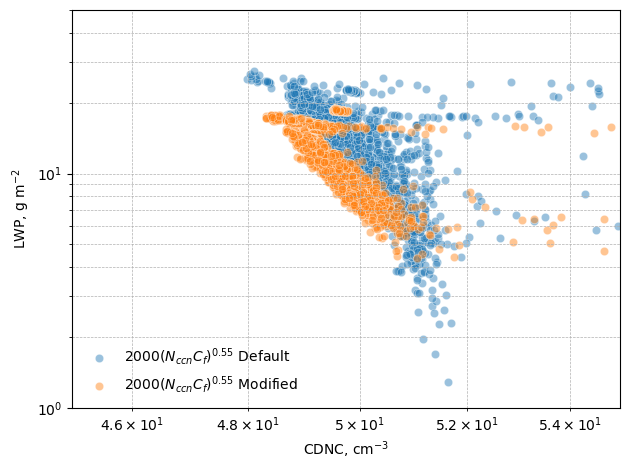

In [123]:
to_plot = ["scream_dpxx_DYCOMSrf01_a2000_p55", "scream_dpxx_DYCOMSrf01_a2000_p55_0ps"]
for exp in to_plot:
    print(exp)
    df = dfs[exp]
    # change color for each experiment
    # colors = plt.cm.BrBG(np.linspace(0, 1, len(to_plot)))
    # color = colors[to_plot.index(exp)]
    a, b = exp.split("_")[3:5]
    a = a.replace("a", "")
    b = b.replace("p", "0.")
    c = "Modified" if exp.endswith("0ps") else "Default"
    sns.scatterplot(data=df, x="cdnc_at_cldtop", y="LiqWaterPath", alpha=0.45, label=f"${a} (N_{{ccn}} C_{{f}})^{{{b}}}$ {c}")
    # Set xscale and yscale to log
    plt.xscale("log"); plt.xlim(4.5e1, 5.5e1)
    plt.yscale("log"); plt.ylim(1e0, 5e1)
    plt.xlabel(f"CDNC, cm$^{{-3}}$")
    plt.ylabel(f"LWP, g m$^{{-2}}$")
    # make the grid at every minor tick
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend(bbox_to_anchor=(1.05, 0.80), loc='upper left', fontsize=10)
# remove the legend
plt.legend(loc='lower left', fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_0ps.png", dpi=300, bbox_inches='tight')

In [126]:
data["scream_dpxx_DYCOMSrf01_a2000_p55"].nc.mean().values, data["scream_dpxx_DYCOMSrf01_a2000_p55_0ps"].nc.mean().values

(array(3380149.8, dtype=float32), array(3132608., dtype=float32))